# Algorytmy Ewolucyjne – Projekt 2: Problem Plecakowy
**Algorytm genetyczny z kodowaniem binarnym dla problemu 0/1 plecakowego**

32 przedmioty, $W = 30\%$ sumy wag, selekcja turniejowa, krzyżowanie dwupunktowe, mutacja bitowa.

In [13]:
%load_ext autoreload
%autoreload 2

import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join(os.getcwd(), 'find_best_backpack'))

from genetic_algorythym.genetic_algorythym import genetic_evolution, chromosome
from genetic_algorythym.genetic_algorythym_prameters import return_genetic_algorithm_parameters

# --- Wczytanie przedmiotów ---
items_df = pd.read_csv('get_all_items/items_337001.csv', sep=';')
weights = items_df['Waga'].values.astype(float)
values  = items_df['Wartosc'].values.astype(float)

total_weight = weights.sum()
MAX_WEIGHT   = 0.30 * total_weight

print(f"Suma wag wszystkich przedmiotów : {total_weight:.1f}")
print(f"Maksymalna waga plecaka  W=30%  : {MAX_WEIGHT:.2f}")

# --- Ustawienie zmiennych klasowych chromosomu ---
chromosome.weights    = weights
chromosome.values     = values
chromosome.max_weight = MAX_WEIGHT

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Suma wag wszystkich przedmiotów : 15.1
Maksymalna waga plecaka  W=30%  : 4.53


## Lista przedmiotów

In [14]:
print(items_df.to_string(index=False))

 ID_Przedmiotu  Waga  Wartosc
             1   0.3       78
             2   0.7       27
             3   0.8       79
             4   0.3       30
             5   0.4       30
             6   0.9       28
             7   0.7       38
             8   0.8       94
             9   0.1        6
            10   1.0       94
            11   0.3       49
            12   0.9       91
            13   0.3       55
            14   0.9       94
            15   0.1       35
            16   0.4       96
            17   0.7       17
            18   0.2       55
            19   0.3       97
            20   0.4       94
            21   0.3       45
            22   0.4       96
            23   0.4       40
            24   0.2       47
            25   0.6       94
            26   0.2       15
            27   0.2       47
            28   0.5       73
            29   0.1       37
            30   0.9      100
            31   0.5       43
            32   0.3       17


## Parametry algorytmu

W celu doboru optymalnego rozmiaru turnieju testowane są cztery wartości $k \in \{1,\,2,\,5,\,10\}$ przy stałych pozostałych parametrach.

| Parametr | Wartość |
|---|---|
| Liczność populacji $N$ | 100 |
| Potomkowie elitarni $N_e$ | 5 |
| Potomkowie skrzyżowani $N_c$ | 80 |
| Potomkowie zmutowani $N_m$ | 15 |
| Prawdopodobieństwo mutacji $p_m$ | $1/32 \approx 0{,}031$ |
| Prawdopodobieństwo krzyżowania $p_c$ | $0{,}8$ |
| Liczba pokoleń | 300 |
| Warunek zatrzymania | stała liczba pokoleń (300) |

In [15]:
base_params = return_genetic_algorithm_parameters()

tournament_sizes = [1, 2, 5, 10]
results = {}

for k in tournament_sizes:
    print(f"Uruchamianie GA  (turniej k={k})...")
    params = {**base_params, "tournament_size": k}
    ga = genetic_evolution(**params)
    best_chrom, best_fitness, history = ga.genetic_algorithm()
    results[k] = {"history": history, "best": best_chrom, "fitness": best_fitness}
    print(f"  Najlepsza wartość: {best_fitness:.0f}\n")

Uruchamianie GA  (turniej k=1)...
  Najlepsza wartość: 953

Uruchamianie GA  (turniej k=2)...
  Najlepsza wartość: 968

Uruchamianie GA  (turniej k=5)...
  Najlepsza wartość: 968

Uruchamianie GA  (turniej k=10)...
  Najlepsza wartość: 968



## Wykresy wartości funkcji celu

Dla każdego uruchomienia: minimum, średnia, maksimum (lewa oś) oraz wariancja (prawa oś) w funkcji numeru pokolenia.

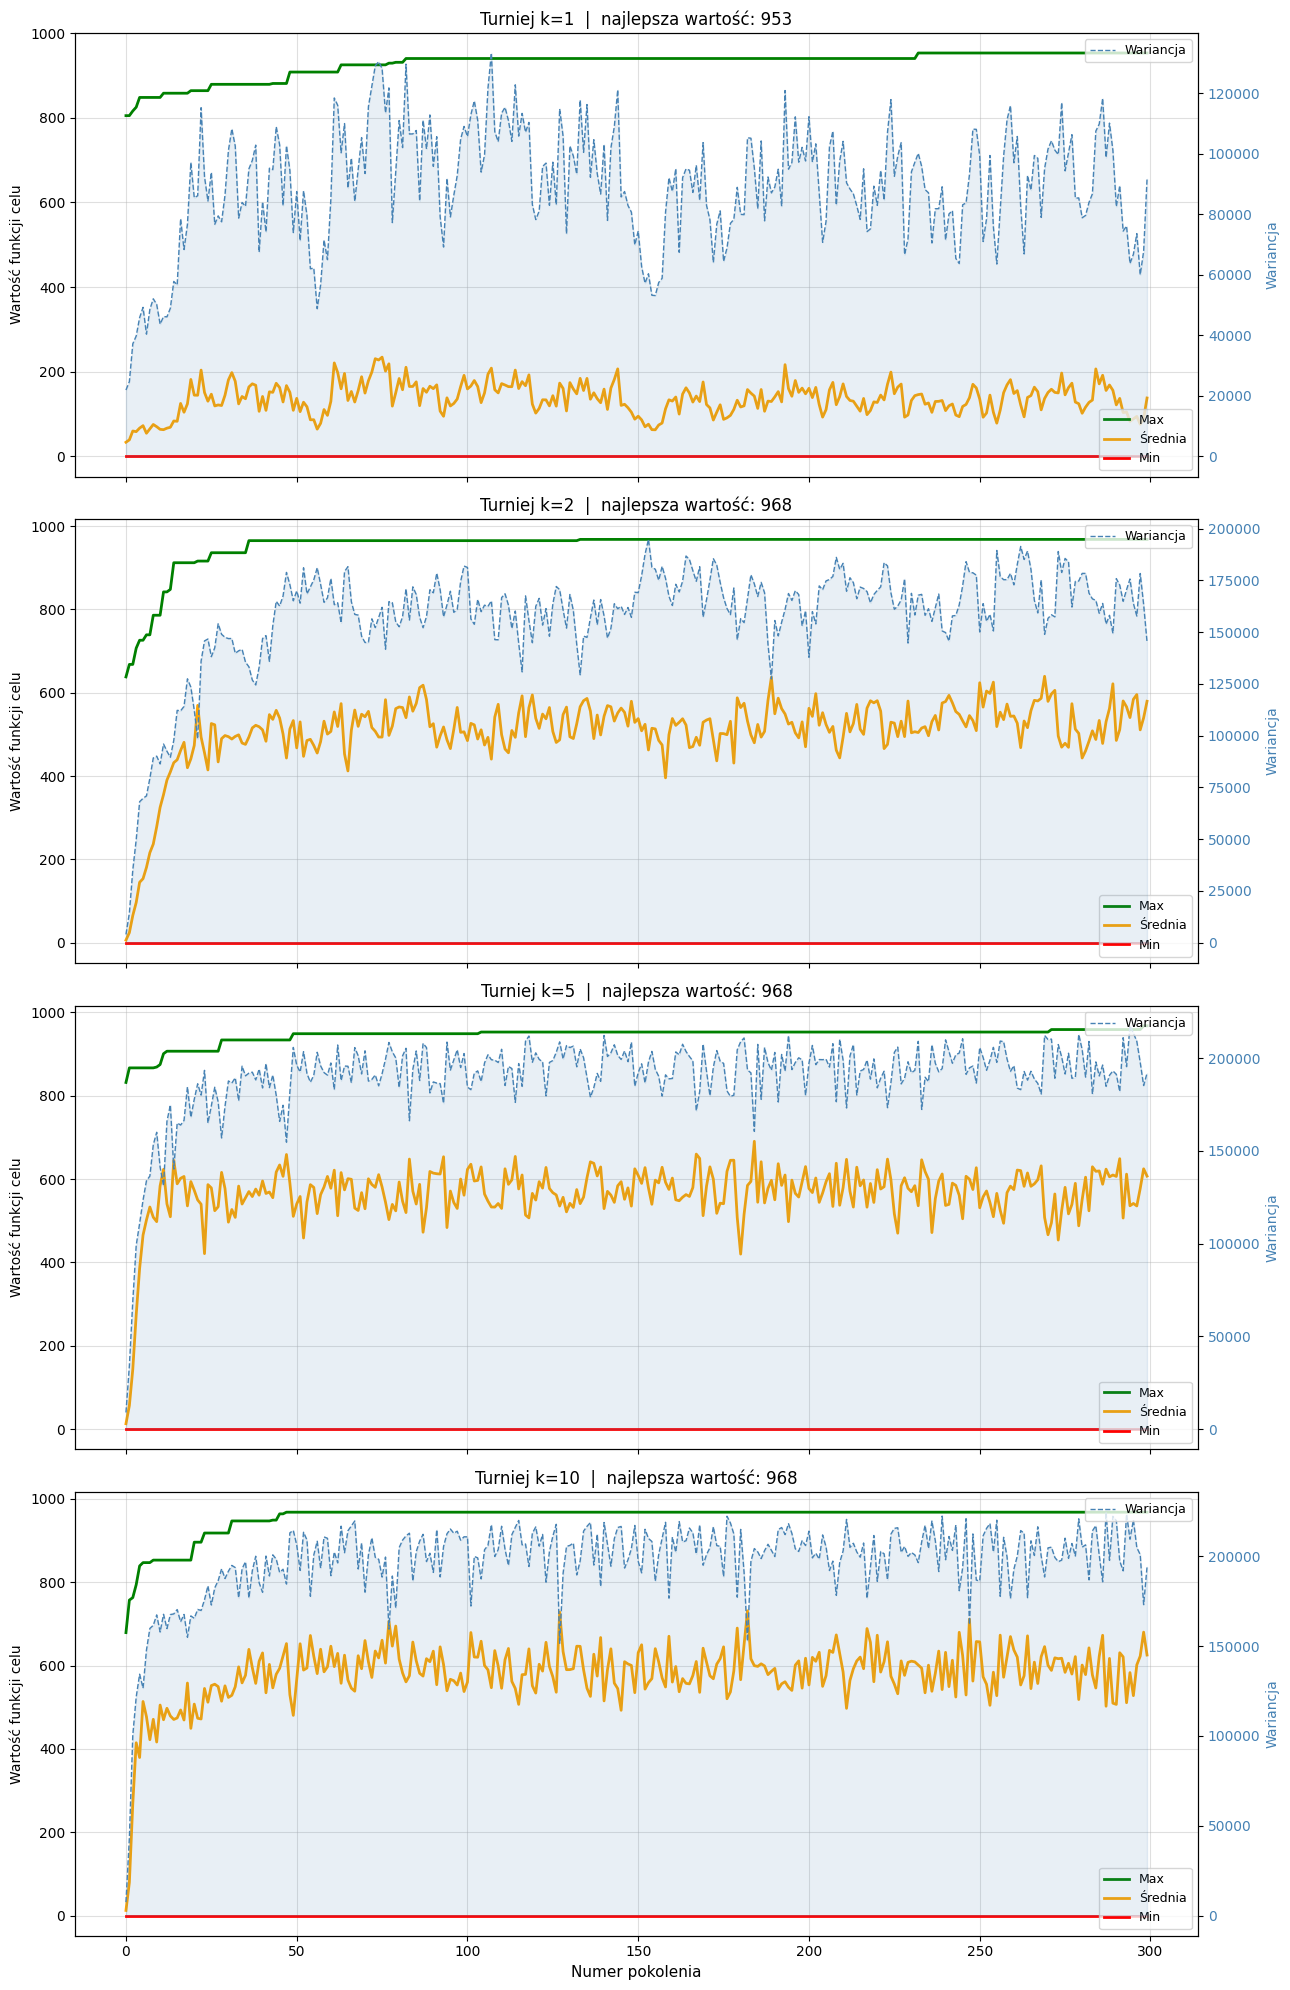

In [16]:
fig, axes = plt.subplots(len(tournament_sizes), 1, figsize=(13, 5 * len(tournament_sizes)), sharex=True)

for ax, k in zip(axes, tournament_sizes):
    h    = results[k]["history"]
    gens = range(len(h))

    ax.plot(gens, [e["max"]  for e in h], label="Max",     color="green",  linewidth=2)
    ax.plot(gens, [e["mean"] for e in h], label="Średnia", color="orange", linewidth=2)
    ax.plot(gens, [e["min"]  for e in h], label="Min",     color="red",    linewidth=2)
    ax.set_ylabel("Wartość funkcji celu", fontsize=10)
    ax.set_title(f"Turniej k={k}  |  najlepsza wartość: {results[k]['fitness']:.0f}", fontsize=12)
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(True, alpha=0.4)

    ax2 = ax.twinx()
    ax2.fill_between(gens, [e["var"] for e in h], alpha=0.12, color="steelblue")
    ax2.plot(gens, [e["var"] for e in h], color="steelblue", linewidth=1, linestyle="--", label="Wariancja")
    ax2.set_ylabel("Wariancja", color="steelblue", fontsize=10)
    ax2.tick_params(axis="y", labelcolor="steelblue")
    ax2.legend(loc="upper right", fontsize=9)

axes[-1].set_xlabel("Numer pokolenia", fontsize=11)
plt.tight_layout()
plt.show()

## Dobór optymalnych parametrów

**Warunek zatrzymania:** stała liczba pokoleń (300). Dobrana empirycznie — na podstawie powyższych wykresów widać, że wartość najlepszego osobnika stabilizuje się przed pokoleniem 250 we wszystkich testowanych konfiguracjach. Dalsze iteracje nie poprawiają wyniku.

**Metoda selekcji i rozmiar turnieju $k$:** jako kryterium doboru przyjęto najwyższą wartość funkcji celu uzyskaną przez najlepszego osobnika w całym przebiegu. Poniższa tabela podsumowuje wyniki wszystkich uruchomień — konfiguracją optymalną jest ta z najwyższą wartością.

In [17]:
print(f"{'Turniej k':>12} | {'Najlepsza wartość':>18} | {'Średnia końcowa':>16} | {'Wariancja końcowa':>17}")
print("-" * 70)
for k in tournament_sizes:
    h = results[k]["history"]
    print(f"{k:>12} | {results[k]['fitness']:>18.0f} | {h[-1]['mean']:>16.1f} | {h[-1]['var']:>17.1f}")

optimal_k = max(tournament_sizes, key=lambda k: results[k]["fitness"])
print(f"\nOptymalna konfiguracja: turniej k={optimal_k}  →  wartość: {results[optimal_k]['fitness']:.0f}")

   Turniej k |  Najlepsza wartość |  Średnia końcowa | Wariancja końcowa
----------------------------------------------------------------------
           1 |                953 |            137.9 |           91684.7
           2 |                968 |            579.5 |          145179.6
           5 |                968 |            607.2 |          191925.9
          10 |                968 |            625.2 |          194059.3

Optymalna konfiguracja: turniej k=2  →  wartość: 968


## Najlepsze rozwiązanie

In [18]:
genes    = results[optimal_k]["best"].genes
sel_mask = np.array(genes, dtype=bool)

total_sel_weight = float(np.dot(genes, weights))
total_sel_value  = float(np.dot(genes, values))

print(f"Optymalna konfiguracja: turniej k={optimal_k}\n")
print("Wektor binarny rozwiązania:")
print(genes)
print(f"\nWybrane przedmioty ({sel_mask.sum()} z {len(genes)}):")
print(items_df[sel_mask].to_string(index=False))
print(f"\nSumaryczna waga   : {total_sel_weight:.1f}  ≤  {MAX_WEIGHT:.2f}  (limit W)")
print(f"Sumaryczna wartość: {total_sel_value:.0f}")

Optymalna konfiguracja: turniej k=2

Wektor binarny rozwiązania:
[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0]

Wybrane przedmioty (15 z 32):
 ID_Przedmiotu  Waga  Wartosc
             1   0.3       78
            11   0.3       49
            13   0.3       55
            15   0.1       35
            16   0.4       96
            18   0.2       55
            19   0.3       97
            20   0.4       94
            22   0.4       96
            24   0.2       47
            25   0.6       94
            26   0.2       15
            27   0.2       47
            28   0.5       73
            29   0.1       37

Sumaryczna waga   : 4.5  ≤  4.53  (limit W)
Sumaryczna wartość: 968
